In [1]:
"""
7 种评估方法对比:
  1. Train-Test Split (80/20) — 展示结果不稳定性
  2. K-Fold CV (5-fold, 10-fold) — 为什么比单次划分可靠
  3. Stratified K-Fold — 保持每折类别比例
  4. Repeated K-Fold — 多次重复取平均
  5. Repeated Stratified K-Fold — 组合优势
  6. Leave-One-Out (LOOCV) — 优缺点分析
  7. Nested Cross Validation — 避免调参偏倚 (高水平论文标配)
哪种评估最可信?
=============================================================================
"""

'\n7 种评估方法对比:\n  1. Train-Test Split (80/20) — 展示结果不稳定性\n  2. K-Fold CV (5-fold, 10-fold) — 为什么比单次划分可靠\n  3. Stratified K-Fold — 保持每折类别比例\n  4. Repeated K-Fold — 多次重复取平均\n  5. Repeated Stratified K-Fold — 组合优势\n  6. Leave-One-Out (LOOCV) — 优缺点分析\n  7. Nested Cross Validation — 避免调参偏倚 (高水平论文标配)\n哪种评估最可信?\n=============================================================================\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import (train_test_split, KFold, StratifiedKFold,
                                     RepeatedKFold, RepeatedStratifiedKFold,
                                     LeaveOneOut, cross_val_score,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, brier_score_loss
%matplotlib inline
warnings.filterwarnings('ignore')


In [3]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 20000
N_LOOCV = 500      # LOOCV 用小样本

In [4]:

# ============================================================================
# 0. 数据加载 & 预处理
# ============================================================================
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

print(f"    样本量: {len(df):,}  (VIVO: {(df['target'] == 1).sum():,} = {(df['target'] == 1).mean()*100:.2f}%)")

# 特征准备 (同案例 7)
feature_cols = ['Age', 'year', 'Gender', 'Code.Profession',
                'Diagnostic.means', 'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Gender', 'Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values

# ---------- 建立基础 Pipeline ----------
def create_pipeline(C=1.0):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, class_weight='balanced',
                                   max_iter=5000, random_state=RANDOM_STATE))
    ])

print(f"    特征数: {len(feature_cols)}")


[0] 加载数据...
    样本量: 20,000  (VIVO: 8,230 = 41.15%)
    特征数: 7


# 第一部分: Train-Test Split — 结果不稳定性演示

In [5]:

split_results = []
n_trials = 20

print(f"\n  重复 {n_trials} 次随机的 80/20 划分:")
for seed in range(n_trials):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    pipe = create_pipeline()
    pipe.fit(X_tr, y_tr)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_prob)
    split_results.append({'Seed': seed, 'AUC': auc})

    if seed < 5 or seed == n_trials - 1:
        print(f"    seed={seed:>2}: AUC={auc:.4f}")

split_aucs = [r['AUC'] for r in split_results]
print(f"\n  mean AUC = {np.mean(split_aucs):.4f} ± {np.std(split_aucs):.4f}")
print(f"  min = {min(split_aucs):.4f}, max = {max(split_aucs):.4f}")
print(f"  极差 (range) = {max(split_aucs) - min(split_aucs):.4f}")


  重复 20 次随机的 80/20 划分:
    seed= 0: AUC=0.8979
    seed= 1: AUC=0.8958
    seed= 2: AUC=0.8953
    seed= 3: AUC=0.8839
    seed= 4: AUC=0.8908
    seed=19: AUC=0.8883

  mean AUC = 0.8920 ± 0.0040
  min = 0.8839, max = 0.8990
  极差 (range) = 0.0151



  [图] 11a_split_instability.png → 划分结果不稳定性已保存


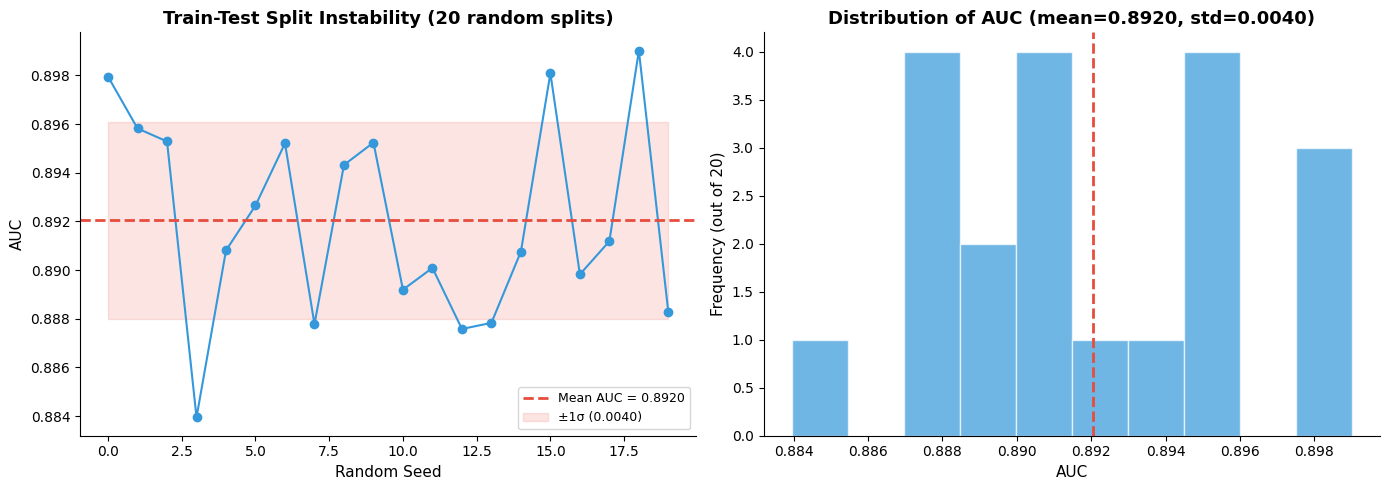

In [6]:
# 可视化 20 次划分的结果波动
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
y_vals = [r['AUC'] for r in split_results]
x_vals = [r['Seed'] for r in split_results]
ax.plot(x_vals, y_vals, 'o-', color='#3498db', linewidth=1.5, markersize=6)
ax.axhline(y=np.mean(y_vals), color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Mean AUC = {np.mean(y_vals):.4f}')
ax.fill_between(x_vals,
                 [np.mean(y_vals) - np.std(y_vals)] * len(y_vals),
                 [np.mean(y_vals) + np.std(y_vals)] * len(y_vals),
                 alpha=0.15, color='#e74c3c', label=f'±1σ ({np.std(y_vals):.4f})')
ax.set_xlabel('Random Seed', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('Train-Test Split Instability (20 random splits)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
ax.hist(y_vals, bins=10, color='#3498db', edgecolor='white', alpha=0.7)
ax.axvline(x=np.mean(y_vals), color='#e74c3c', linestyle='--', linewidth=2)
ax.set_xlabel('AUC', fontsize=11)
ax.set_ylabel('Frequency (out of 20)', fontsize=11)
ax.set_title(f'Distribution of AUC (mean={np.mean(y_vals):.4f}, std={np.std(y_vals):.4f})',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11a_split_instability.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11a_split_instability.png → 划分结果不稳定性已保存")

# 第二部分: K-Fold CV (5, 10) & 第三部分: Stratified K-Fold

In [7]:

cv_methods = {
    '5-Fold': KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    '10-Fold': KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    'Stratified 5-Fold': StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    'Stratified 10-Fold': StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
}

kfold_results = {}

for name, cv in cv_methods.items():
    scores = cross_val_score(create_pipeline(), X, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    kfold_results[name] = {
        'scores': scores,
        'mean': np.mean(scores),
        'std': np.std(scores),
        'min': np.min(scores),
        'max': np.max(scores),
    }
    print(f"  {name:<20}: AUC = {np.mean(scores):.4f} ± {np.std(scores):.4f}")
    print(f"    {'':20}  range = [{np.min(scores):.4f}, {np.max(scores):.4f}]")
    for i, s in enumerate(scores):
        print(f"    {'':20}  fold {i+1}: AUC = {s:.4f}")

  5-Fold              : AUC = 0.8914 ± 0.0042
                          range = [0.8848, 0.8960]
                          fold 1: AUC = 0.8900
                          fold 2: AUC = 0.8959
                          fold 3: AUC = 0.8848
                          fold 4: AUC = 0.8960
                          fold 5: AUC = 0.8902
  10-Fold             : AUC = 0.8914 ± 0.0048
                          range = [0.8820, 0.8992]
                          fold 1: AUC = 0.8880
                          fold 2: AUC = 0.8911
                          fold 3: AUC = 0.8957
                          fold 4: AUC = 0.8964
                          fold 5: AUC = 0.8881
                          fold 6: AUC = 0.8820
                          fold 7: AUC = 0.8927
                          fold 8: AUC = 0.8992
                          fold 9: AUC = 0.8930
                          fold 10: AUC = 0.8875
  Stratified 5-Fold   : AUC = 0.8913 ± 0.0027
                          range = [0.8863, 0.8945]
   


  [图] 11b_kfold_comparison.png → K-Fold 对比已保存


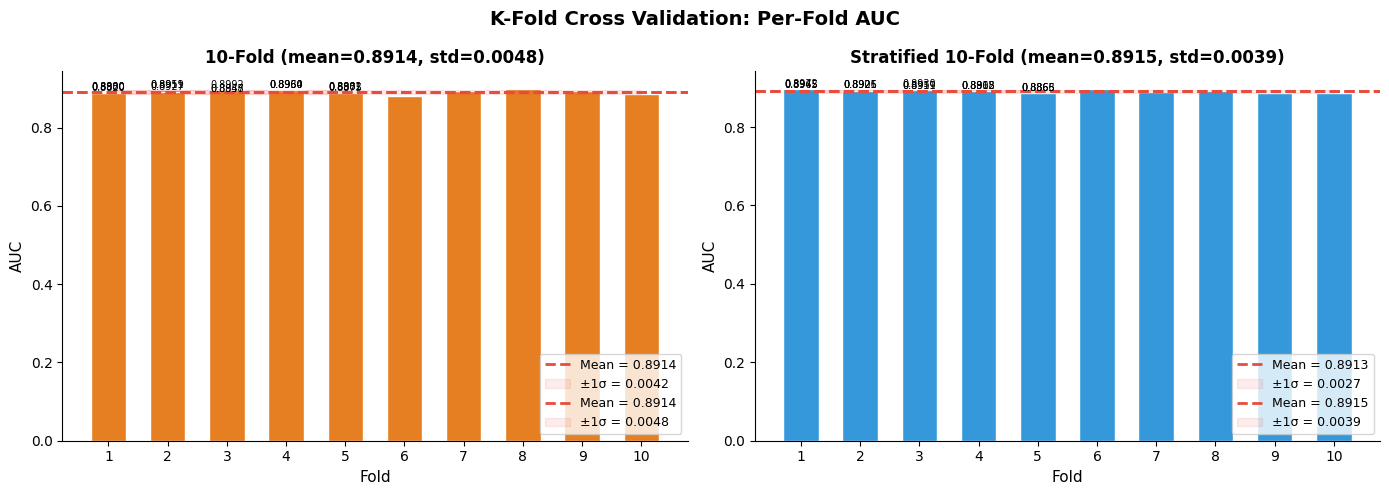

In [8]:
# 5-Fold vs Stratified 5-Fold 对比图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (name, data) in enumerate(kfold_results.items()):
    ax = axes[idx // 2]
    scores = data['scores']
    x_pos = np.arange(len(scores)) + 1
    colors_f = ['#3498db' if 'Stratified' in name else '#e67e22'] * len(scores)
    ax.bar(x_pos, scores, color=colors_f, edgecolor='white', width=0.6)
    ax.axhline(y=data['mean'], color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Mean = {data["mean"]:.4f}')
    ax.fill_between(x_pos,
                     [data['mean'] - data['std']] * len(scores),
                     [data['mean'] + data['std']] * len(scores),
                     alpha=0.1, color='#e74c3c', label=f'±1σ = {data["std"]:.4f}')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(f'{name} (mean={data["mean"]:.4f}, std={data["std"]:.4f})',
                 fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    for bar, s in zip(ax.patches, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{s:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('K-Fold Cross Validation: Per-Fold AUC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11b_kfold_comparison.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11b_kfold_comparison.png → K-Fold 对比已保存")

# 第四部分 & 第五部分: Repeated K-Fold & Repeated Stratified K-Fold

In [9]:
repeated_methods = {
    'Repeated 5-Fold (10x)': RepeatedKFold(
        n_splits=5, n_repeats=10, random_state=RANDOM_STATE),
    'Repeated Stratified 5-Fold (10x)': RepeatedStratifiedKFold(
        n_splits=5, n_repeats=10, random_state=RANDOM_STATE),
}

repeated_results = {}

for name, cv in repeated_methods.items():
    print(f"\n  正在运行 {name}... (50 个模型)")
    start_t = time.time()
    scores_all = []
    fold_aucs = []
    for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X, y)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        pipe = create_pipeline()
        pipe.fit(X_tr, y_tr)
        auc = roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1])
        scores_all.append(auc)
        fold_aucs.append(auc)

    elapsed = time.time() - start_t
    repeated_results[name] = {
        'scores': np.array(scores_all),
        'mean': np.mean(scores_all),
        'std': np.std(scores_all),
        'min': np.min(scores_all),
        'max': np.max(scores_all),
        'time': elapsed
    }
    print(f"    AUC = {np.mean(scores_all):.4f} ± {np.std(scores_all):.4f}")
    print(f"    min = {np.min(scores_all):.4f}, max = {np.max(scores_all):.4f}")
    print(f"    耗时: {elapsed:.1f}s")


  正在运行 Repeated 5-Fold (10x)... (50 个模型)
    AUC = 0.8915 ± 0.0046
    min = 0.8838, max = 0.9005
    耗时: 0.7s

  正在运行 Repeated Stratified 5-Fold (10x)... (50 个模型)
    AUC = 0.8914 ± 0.0040
    min = 0.8810, max = 0.9004
    耗时: 0.7s


In [10]:
print("\n  标准差对比:")
print(f"    5-Fold (单次):    σ = {kfold_results['5-Fold']['std']:.4f}")
print(f"    Repeated 5-Fold: σ = {repeated_results['Repeated 5-Fold (10x)']['std']:.4f}")
print(f"    Stratified 5-Fold (单次): σ = {kfold_results['Stratified 5-Fold']['std']:.4f}")
print(f"    Repeated Stratified 5-Fold: σ = {repeated_results['Repeated Stratified 5-Fold (10x)']['std']:.4f}")



  标准差对比:
    5-Fold (单次):    σ = 0.0042
    Repeated 5-Fold: σ = 0.0046
    Stratified 5-Fold (单次): σ = 0.0027
    Repeated Stratified 5-Fold: σ = 0.0040



  [图] 11c_repeated_cv.png → Repeated CV 已保存


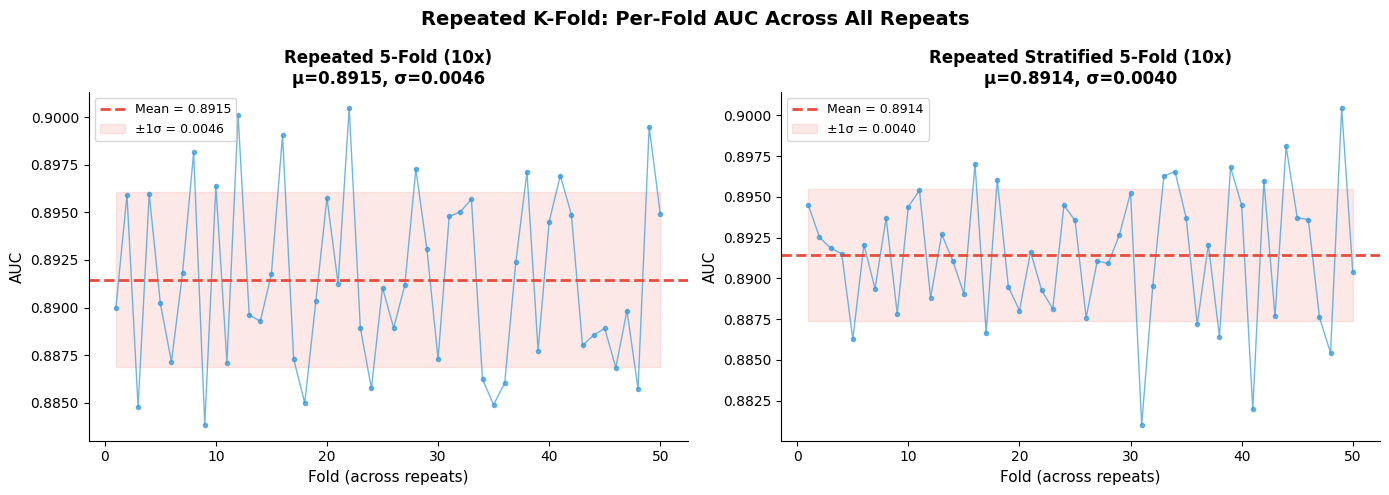

In [11]:
# Repeated CV 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, (name, data) in enumerate(repeated_results.items()):
    ax = axes[idx]
    scores = data['scores']
    ax.plot(range(1, len(scores) + 1), scores, 'o-', color='#3498db',
            linewidth=1, markersize=3, alpha=0.7)
    ax.axhline(y=data['mean'], color='#e74c3c', linestyle='--', linewidth=2,
               label=f'Mean = {data["mean"]:.4f}')
    ax.fill_between(range(1, len(scores) + 1),
                     [data['mean'] - data['std']] * len(scores),
                     [data['mean'] + data['std']] * len(scores),
                     alpha=0.12, color='#e74c3c', label=f'±1σ = {data["std"]:.4f}')
    ax.set_xlabel('Fold (across repeats)', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(f'{name}\nμ={data["mean"]:.4f}, σ={data["std"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Repeated K-Fold: Per-Fold AUC Across All Repeats',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11c_repeated_cv.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11c_repeated_cv.png → Repeated CV 已保存")

# 第六部分: LOOCV (小样本)

In [12]:
# 取小样本做 LOOCV
np.random.seed(RANDOM_STATE)
if len(X) > N_LOOCV:
    loocv_idx = np.random.choice(len(X), N_LOOCV, replace=False)
    X_loocv = X[loocv_idx]
    y_loocv = y[loocv_idx]
else:
    X_loocv, y_loocv = X.copy(), y.copy()

n_loocv = len(X_loocv)
print(f"\n  样本量: {n_loocv} (LOOCV 会训练 {n_loocv} 个模型)")

loocv = LeaveOneOut()
loocv_preds = []
start_t = time.time()
n_reported = 0

for tr_idx, te_idx in loocv.split(X_loocv, y_loocv):
    pipe = create_pipeline()
    pipe.fit(X_loocv[tr_idx], y_loocv[tr_idx])
    loocv_preds.append(pipe.predict_proba(X_loocv[te_idx])[:, 1][0])
    n_reported += 1

loocv_time = time.time() - start_t
loocv_auc = roc_auc_score(y_loocv, loocv_preds)
print(f"  LOOCV AUC = {loocv_auc:.4f}")
print(f"  LOOCV 耗时: {loocv_time:.1f}s (n={n_loocv})")
print(f"  预估全数据 LOOCV 耗时: {loocv_time * len(X) / n_loocv / 3600:.1f} 小时")


  样本量: 500 (LOOCV 会训练 500 个模型)
  LOOCV AUC = 0.8870
  LOOCV 耗时: 0.6s (n=500)
  预估全数据 LOOCV 耗时: 0.0 小时


  同样本 Stratified 5-Fold: AUC = 0.8907 ± 0.0271

  [图] 11d_loocv_cost.png → LOOCV 计算成本图已保存


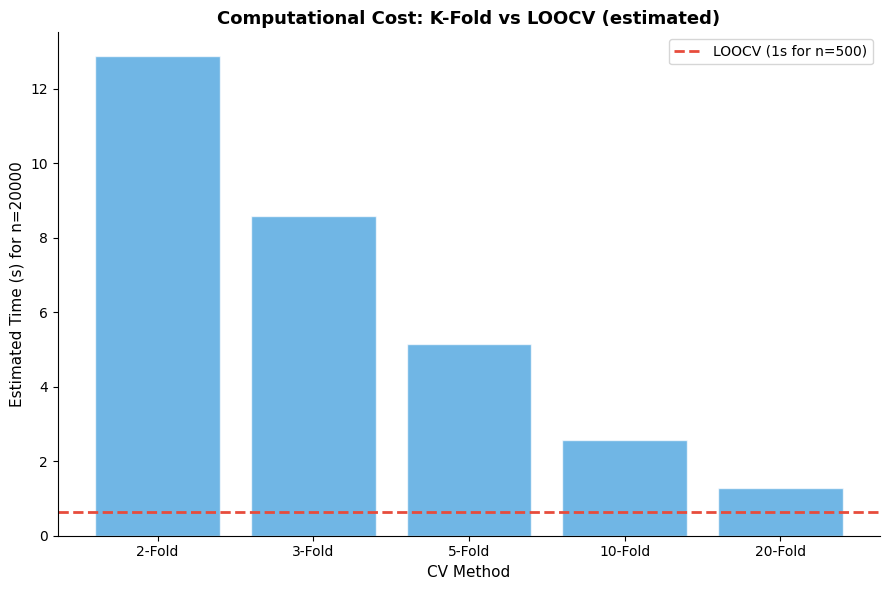

In [13]:
# 对比: 同样本量下的 Stratified 5-Fold
cv_small = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
small_scores = cross_val_score(create_pipeline(), X_loocv, y_loocv,
                                cv=cv_small, scoring='roc_auc', n_jobs=-1)
print(f"  同样本 Stratified 5-Fold: AUC = {np.mean(small_scores):.4f} ± {np.std(small_scores):.4f}")

# LOOCV 耗时 vs 折数对比图
fig, ax = plt.subplots(figsize=(9, 6))
k_values = [2, 3, 5, 10, 20]
times_est = [loocv_time * n_loocv / k / n_loocv for k in k_values]  # wrong, let me recalculate

# 正确估算: LOOCV = n 次训练
# K-Fold = n 次训练 / k 折 * 1 轮
loocv_per_sample = loocv_time / n_loocv
times_kfold = [loocv_per_sample * len(X) / k for k in k_values]

ax.bar([f'{k}-Fold' for k in k_values], times_kfold,
       color='#3498db', edgecolor='white', alpha=0.7)
ax.axhline(y=loocv_time, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'LOOCV ({loocv_time:.0f}s for n={n_loocv})')
ax.set_xlabel('CV Method', fontsize=11)
ax.set_ylabel(f'Estimated Time (s) for n={len(X)}', fontsize=11)
ax.set_title('Computational Cost: K-Fold vs LOOCV (estimated)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11d_loocv_cost.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11d_loocv_cost.png → LOOCV 计算成本图已保存")

# 第七部分: Nested Cross Validation

In [14]:
n_nested = 5000  # 嵌套 CV 计算量大，用小样本
np.random.seed(RANDOM_STATE)
if len(X) > n_nested:
    nest_idx = np.random.choice(len(X), n_nested, replace=False)
    X_nest = X[nest_idx]
    y_nest = y[nest_idx]
else:
    X_nest, y_nest = X.copy(), y.copy()

print(f"\n  样本量: {len(X_nest):,}")
print(f"  外折: 5-fold | 内折: 3-fold (共 5 × 3 = 15 个模型)")

param_grid = {'lr__C': [0.01, 0.1, 1, 10]}

# --- 不嵌套的 CV (泄漏版) — 全数据选参 → 在外折上评估 ---
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
# 在内层用全部分组做 CV 选参
gs_leak = GridSearchCV(create_pipeline(), param_grid, cv=3, scoring='roc_auc')
gs_leak_scores = cross_val_score(gs_leak, X_nest, y_nest, cv=outer_cv, scoring='roc_auc')

print(f"\n  [不嵌套 CV] 全数据 GridSearch → 外折评估:")
print(f"    AUC = {np.mean(gs_leak_scores):.4f} ± {np.std(gs_leak_scores):.4f}")

# --- Nested CV: 内层 CV 选参 → 外层 CV 评估 (只在训练折上选参) ---
print(f"\n  [Nested CV] 每折独立做内层 GridSearch:")
nested_scores = []
best_params_per_fold = []
start_t = time.time()

for outer_idx, (tr_idx, te_idx) in enumerate(outer_cv.split(X_nest, y_nest)):
    X_tr_n, X_te_n = X_nest[tr_idx], X_nest[te_idx]
    y_tr_n, y_te_n = y_nest[tr_idx], y_nest[te_idx]

    # 内层 CV 选参 (只在训练折上)
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    gs_inner = GridSearchCV(create_pipeline(), param_grid, cv=inner_cv,
                            scoring='roc_auc')
    gs_inner.fit(X_tr_n, y_tr_n)
    best_C = gs_inner.best_params_['lr__C']
    best_params_per_fold.append(best_C)

    # 用最佳参数在外折测试集上评估
    best_pipe = create_pipeline(C=best_C)
    best_pipe.fit(X_tr_n, y_tr_n)
    auc_fold = roc_auc_score(y_te_n, best_pipe.predict_proba(X_te_n)[:, 1])
    nested_scores.append(auc_fold)

    print(f"    外折 {outer_idx+1}: 最佳 C={best_C}, AUC={auc_fold:.4f}")

nested_time = time.time() - start_t
nested_auc_mean = np.mean(nested_scores)
nested_auc_std = np.std(nested_scores)

print(f"\n    Nested CV AUC = {nested_auc_mean:.4f} ± {nested_auc_std:.4f}")
print(f"    不同外折选择的 C 值: {best_params_per_fold}")
print(f"    耗时: {nested_time:.1f}s")

# 对比: 用固定 C=1 (无调参) 的 CV
fixed_cv_scores = cross_val_score(
    create_pipeline(C=1.0), X_nest, y_nest,
    cv=outer_cv, scoring='roc_auc')
print(f"\n  [固定 C=1] 无调参 CV:")
print(f"    AUC = {np.mean(fixed_cv_scores):.4f} ± {np.std(fixed_cv_scores):.4f}")


  样本量: 5,000
  外折: 5-fold | 内折: 3-fold (共 5 × 3 = 15 个模型)

  [不嵌套 CV] 全数据 GridSearch → 外折评估:
    AUC = 0.8952 ± 0.0031

  [Nested CV] 每折独立做内层 GridSearch:
    外折 1: 最佳 C=0.01, AUC=0.9000
    外折 2: 最佳 C=0.01, AUC=0.8967
    外折 3: 最佳 C=0.01, AUC=0.8953
    外折 4: 最佳 C=0.01, AUC=0.8910
    外折 5: 最佳 C=0.01, AUC=0.8928

    Nested CV AUC = 0.8952 ± 0.0031
    不同外折选择的 C 值: [0.01, 0.01, 0.01, 0.01, 0.01]
    耗时: 0.3s

  [固定 C=1] 无调参 CV:
    AUC = 0.8941 ± 0.0034



  [图] 11e_nested_cv.png → Nested CV 对比已保存


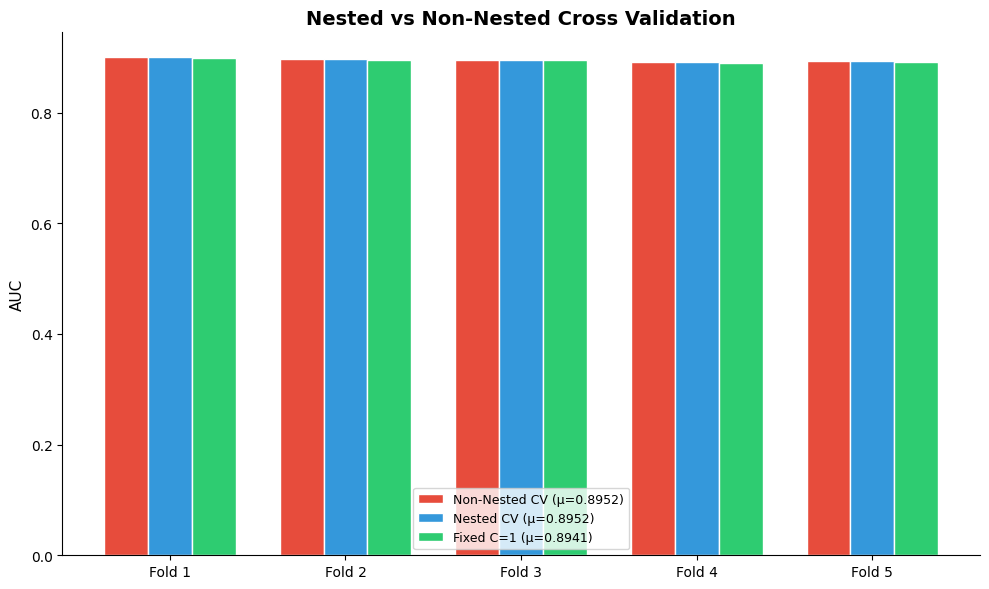

In [15]:
# Nested CV 可视化
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(5)
width = 0.25
ax.bar(x_pos - width, gs_leak_scores, width, color='#e74c3c', edgecolor='white',
       label=f'Non-Nested CV (μ={np.mean(gs_leak_scores):.4f})')
ax.bar(x_pos, nested_scores, width, color='#3498db', edgecolor='white',
       label=f'Nested CV (μ={nested_auc_mean:.4f})')
ax.bar(x_pos + width, fixed_cv_scores, width, color='#2ecc71', edgecolor='white',
       label=f'Fixed C=1 (μ={np.mean(fixed_cv_scores):.4f})')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)], fontsize=10)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('Nested vs Non-Nested Cross Validation',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11e_nested_cv.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11e_nested_cv.png → Nested CV 对比已保存")

In [16]:
summary_rows = []

# 1) Train-Test Split
split_auc_mean = np.mean(split_aucs)
split_auc_std = np.std(split_aucs)
summary_rows.append({
    'Method': 'Train-Test Split (80/20)',
    'AUC_Mean': split_auc_mean,
    'AUC_Std': split_auc_std,
    'Note': f'Across {n_trials} random splits'
})

# 2-5) K-Fold / Stratified
for name in ['5-Fold', '10-Fold', 'Stratified 5-Fold', 'Stratified 10-Fold']:
    data = kfold_results[name]
    summary_rows.append({
        'Method': name,
        'AUC_Mean': data['mean'],
        'AUC_Std': data['std'],
        'Note': f'{len(data["scores"])} folds'
    })

# 6) Repeated K-Fold
for name in ['Repeated 5-Fold (10x)', 'Repeated Stratified 5-Fold (10x)']:
    data = repeated_results[name]
    summary_rows.append({
        'Method': name,
        'AUC_Mean': data['mean'],
        'AUC_Std': data['std'],
        'Note': f'50 folds total'
    })

# 7) LOOCV
summary_rows.append({
    'Method': 'LOOCV',
    'AUC_Mean': loocv_auc,
    'AUC_Std': np.nan,
    'Note': f'n={n_loocv} (subset)'
})

# 8) Nested CV
summary_rows.append({
    'Method': 'Nested CV',
    'AUC_Mean': nested_auc_mean,
    'AUC_Std': nested_auc_std,
    'Note': 'outer 5-fold, inner 3-fold'
})

summary_df = pd.DataFrame(summary_rows)

print(f"\n  {'方法':<35} {'AUC(mean)':>10} {'AUC(std)':>10} {'说明':<30}")
print(f"  {'-'*35} {'-'*10} {'-'*10} {'-'*30}")
for _, row in summary_df.iterrows():
    std_str = f'{row["AUC_Std"]:.4f}' if not np.isnan(row['AUC_Std']) else 'N/A'
    print(f"  {row['Method']:<35} {row['AUC_Mean']:>10.4f} {std_str:>10} {row['Note']:<30}")

# 可信度排序
print(f"\n  {'─'*85}")
print(f"  可信度排序 (标准误差越小 → 越可信):")
sorted_df = summary_df.dropna(subset=['AUC_Std']).sort_values('AUC_Std')
for rank, (_, row) in enumerate(sorted_df.iterrows(), 1):
    print(f"    {rank}. {row['Method']:<35} σ={row['AUC_Std']:.4f}")


  方法                                   AUC(mean)   AUC(std) 说明                            
  ----------------------------------- ---------- ---------- ------------------------------
  Train-Test Split (80/20)                0.8920     0.0040 Across 20 random splits       
  5-Fold                                  0.8914     0.0042 5 folds                       
  10-Fold                                 0.8914     0.0048 10 folds                      
  Stratified 5-Fold                       0.8913     0.0027 5 folds                       
  Stratified 10-Fold                      0.8915     0.0039 10 folds                      
  Repeated 5-Fold (10x)                   0.8915     0.0046 50 folds total                
  Repeated Stratified 5-Fold (10x)        0.8914     0.0040 50 folds total                
  LOOCV                                   0.8870        N/A n=500 (subset)                
  Nested CV                               0.8952     0.0031 outer 5-fold, inner 3-fold   


  [图] 11f_all_methods_comparison.png → 全部方法对比图已保存


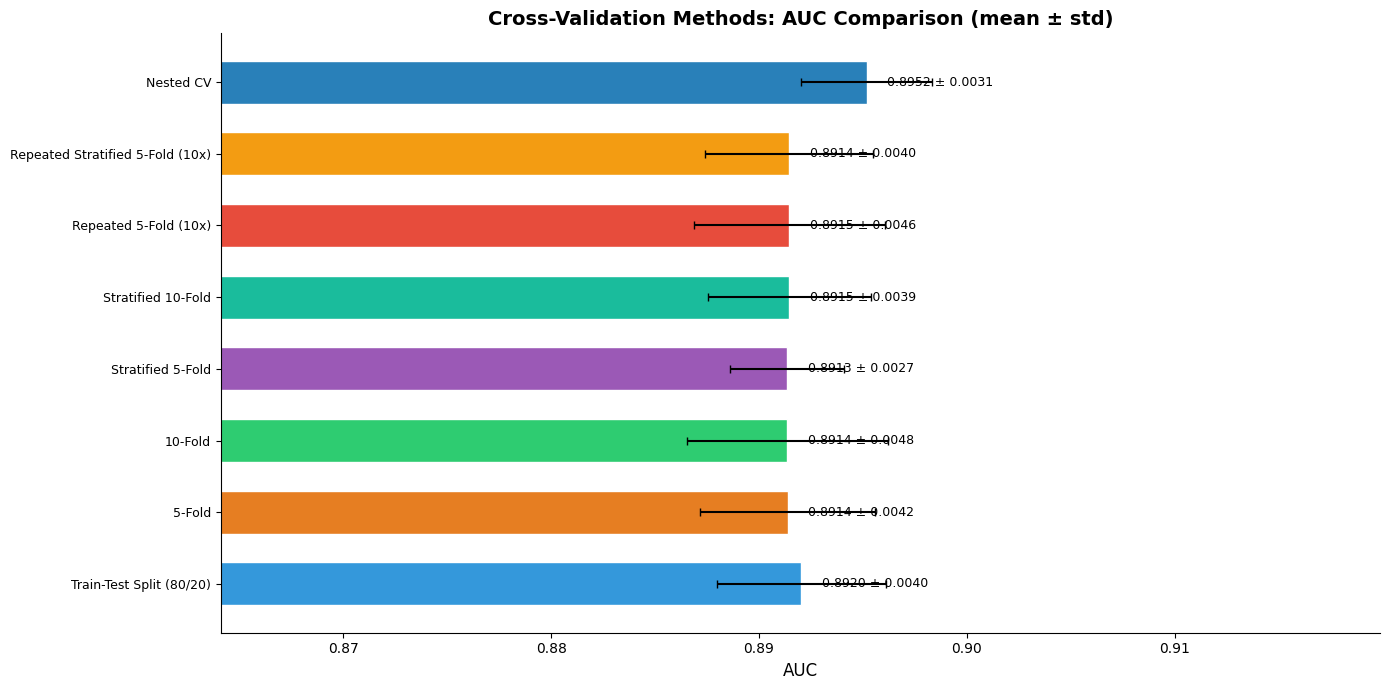

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))
plot_df = summary_df.dropna(subset=['AUC_Std'])
y_pos = np.arange(len(plot_df))
colors_s = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6',
            '#1abc9c', '#e74c3c', '#f39c12', '#2980b9']

ax.barh(y_pos, plot_df['AUC_Mean'].values, xerr=plot_df['AUC_Std'].values,
        color=colors_s[:len(plot_df)], edgecolor='white', capsize=3, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Method'].values, fontsize=9)
ax.set_xlabel('AUC', fontsize=12)
ax.set_xlim([min(plot_df['AUC_Mean'] - plot_df['AUC_Std'] * 1.5) - 0.02,
             max(plot_df['AUC_Mean'] + plot_df['AUC_Std'] * 1.5) + 0.02])
ax.set_title('Cross-Validation Methods: AUC Comparison (mean ± std)',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

for bar, (_, row) in zip(ax.patches, plot_df.iterrows()):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{row["AUC_Mean"]:.4f} ± {row["AUC_Std"]:.4f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "11f_all_methods_comparison.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 11f_all_methods_comparison.png → 全部方法对比图已保存")